1.0 1.0624668681804987 0.9412058201047955
1.0 1.0410426907534356 0.9605754008764696
1.0 1.0190457848784027 0.981310177461089
1.0 0.9964190003731127 1.0035938692714073
1.0 0.9730931607860098 1.0276508358071865
1.0 0.948984168366809 1.0537583590261455
1.0 0.9239873094981035 1.0822659464264563
1.0 0.897969484161089 1.11362358926287
1.0 0.8707561290125269 1.1484271734429718
1.0 0.8421095899111956 1.1874938986331396
1.0 0.8116902298128915 1.2319970886313576
1.0 0.7789786425240836 1.283732242978771
1.0 0.7430990681119909 1.345715588825489
1.0 0.7023197600330895 1.423852861484184


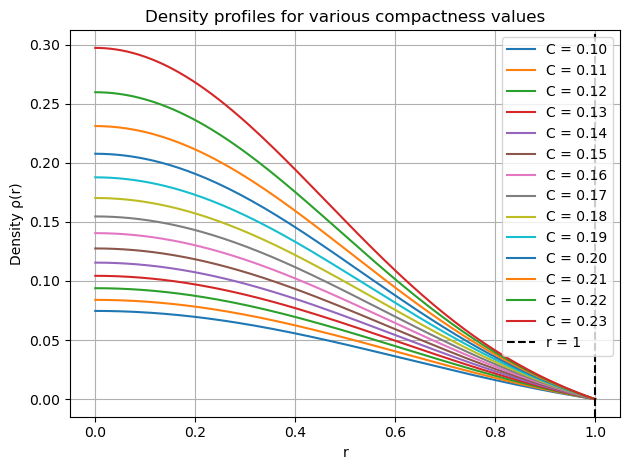

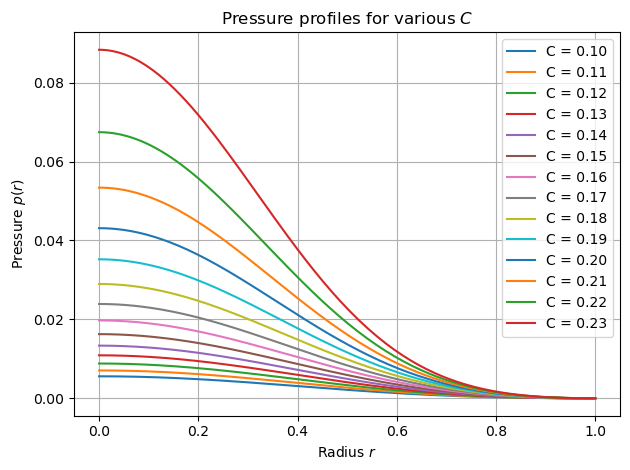

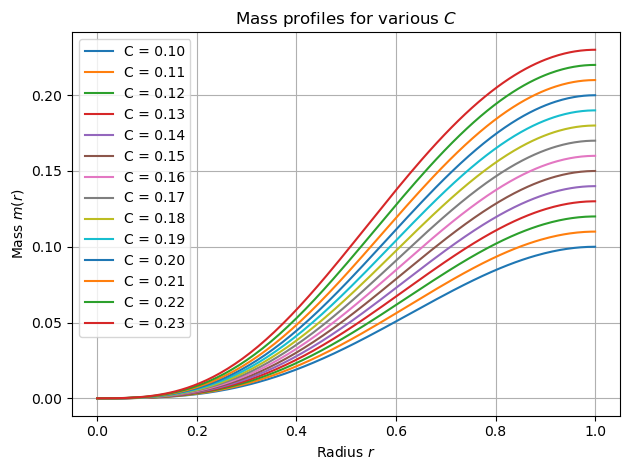

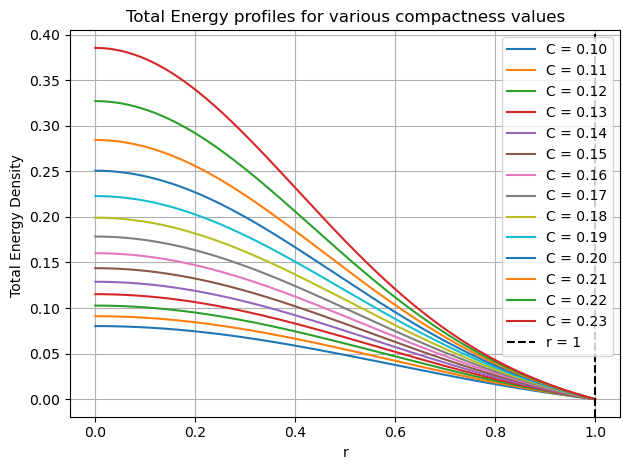

In [39]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d
import matplotlib.pyplot as plt
import cmath as cm

# Constants
K = 1.0             # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


"""def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)"""

def rho_from_p(p):
    return np.sqrt(np.maximum(p, 0.0) / K)

def energy_density_from_p(p):
    rho0 = rho_from_p(p)
    Gamma = 1 + 1/n
    return rho0 + (p/(Gamma-1))  # Total energy density for polytropic EOS


def tov_rhs(r, y):
    p, m, nu = y

    if p <= 0.0:
        return [0.0, 0.0, 0.0]

    rho0 = rho_from_p(p)
    eps  = energy_density_from_p(p) #rho0 + p  # total energy density

    dpdr = -(eps + p) * (m + 4*np.pi*r**3*p) / (r*(r - 2*m))
    dmdr = 4*np.pi * r**2 * eps
    dnudr = -2 * dpdr / (eps + p)

    return [dpdr, dmdr, dnudr]


# Solve TOV for a given p0
def solve_tov(p0, epsi_p = 1e-12): #changing to check for p_cut dependency
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 10],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]
    
    p_cut = epsi_p * p0
    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= p_cut:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (p_cut - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (p_cut - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.24, 0.01), 2)
profiles = {}


for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)

    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    """
    mask = p_vals > p_cut
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]
    """
    
    mask = r_vals <= R_target
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]
    
    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu


    profiles[C_target] = {
        'r': r_vals,
        'r_raw': R_raw,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'TE': energy_density_from_p(p_vals),
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
        'M_raw': M_raw
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho'], label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Total energy
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['TE'], label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Total Energy Density ')
plt.title('Total Energy profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
print("TE = ", profiles[0.2]['TE'][0])
print("rho = ", profiles[0.2]['rho'][0])
print("p = ", profiles[0.2]['p'][0])


TE =  0.25076273570109986
rho =  0.20764591124452905
p =  0.043116824456570835


In [63]:
r_vals = []
M_vals = []

for i in profiles:
    r_vals.append(profiles[i]['r_raw'])
    M_vals.append(profiles[i]['M_raw'])

In [64]:
c = 3e8  # speed of light in m/s
G = 6.67430e-11  # gravitational constant in m^3 kg^-1 s^-2
M_solar = 2e30 #kg 

scaling = (G/c**2)*10*M_solar

In [67]:
G/c**2

7.415888888888889e-28

In [74]:
print("M_raw = ", scaling*profiles[0.15]['M_raw'])
print("r_raw = ", scaling*profiles[0.15]['r_raw'])

M_raw =  2111.26834497496
r_raw =  14075.122299845762


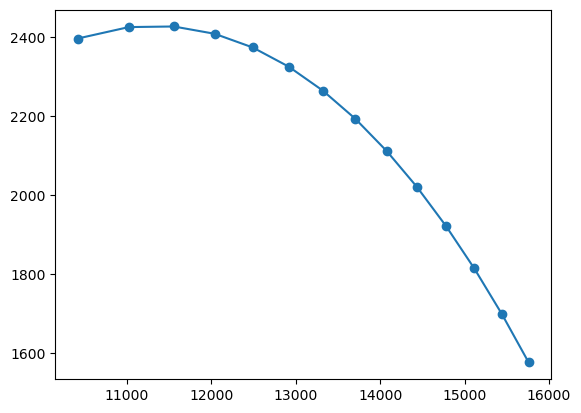

In [66]:
plt.plot(scaling*np.array(r_vals), scaling*np.array(M_vals), marker='o')

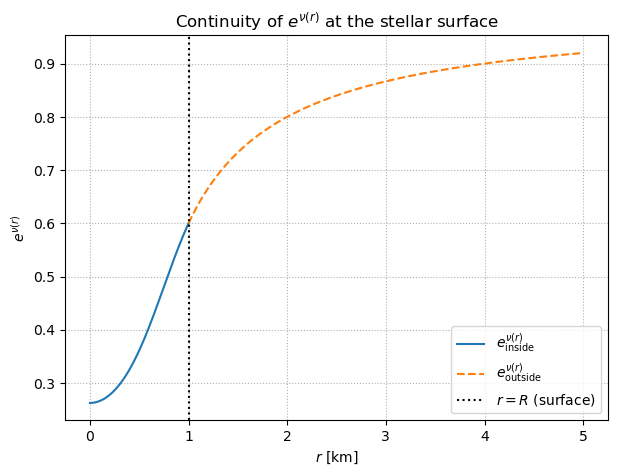

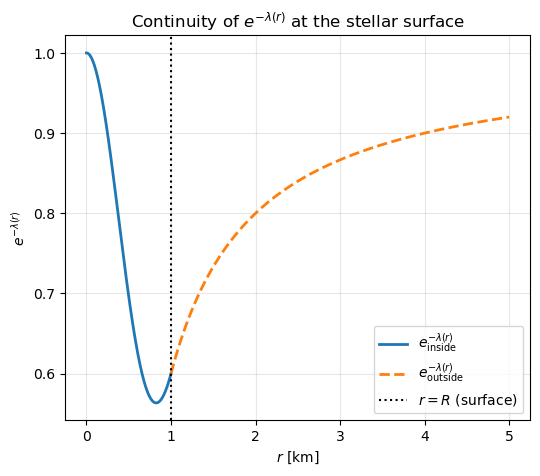

In [40]:
import numpy as np
import matplotlib.pyplot as plt
C = 0.2

M = profiles[C]['M']
R = profiles[C]['R']
nu_in = profiles[C]['nu_vals_norm']
r_in = profiles[C]['r']
m = profiles[C]['m']

def nu_out(r):
    return np.log(1 - 2*M/r)


exp_nu_in = np.exp(nu_in)
r_out = np.linspace(R, 5*R, 200)
exp_nu_out = np.exp(nu_out(r_out))


plt.figure(figsize=(7,5))
plt.plot(r_in, exp_nu_in, label=r'$e^{\nu(r)}_{\mathrm{inside}}$', color='tab:blue')
plt.plot(r_out, exp_nu_out, label=r'$e^{\nu(r)}_{\mathrm{outside}}$', color='tab:orange', linestyle='--')

plt.axvline(R, color='k', linestyle=':', label=r'$r=R$ (surface)')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$e^{\nu(r)}$')
plt.title('Continuity of $e^{\\nu(r)}$ at the stellar surface')
plt.legend()
plt.grid(True, ls=':')
plt.show()


elam_inside = 1 - 2 * m / r_in

r_out = np.linspace(R, 5 * R, 200)
elam_outside = 1 - 2 * M / r_out

plt.figure(figsize=(6,5))
plt.plot(r_in, elam_inside, label=r"$e^{-\lambda(r)}_{\rm inside}$", lw=2)
plt.plot(r_out, elam_outside, '--', label=r"$e^{-\lambda(r)}_{\rm outside}$", lw=2)
plt.axvline(R, color='k', ls=':', label=r"$r = R$ (surface)")
plt.xlabel(r"$r$ [km]")
plt.ylabel(r"$e^{-\lambda(r)}$")
plt.title(r"Continuity of $e^{-\lambda(r)}$ at the stellar surface")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [86]:
class ComplexSpline:
    def __init__(self, x, y, k=3):
        self.real_spline = CubicSpline(x, np.real(y))
        self.imag_spline = CubicSpline(x, np.imag(y))

    def __call__(self, x):
        return self.real_spline(x) + 1j * self.imag_spline(x)

    def derivative(self, n=1):
        der_real = self.real_spline.derivative(n)
        der_imag = self.imag_spline.derivative(n)
        return lambda x: der_real(x) + 1j * der_imag(x)


def lambda_of_r(r, m):
    m_vals = m(r) if callable(m) else m
    return -np.log(1.0 - 2.0 * m_vals / r)

profile= profiles[0.2]
T = 1e5 #Temperature
Ke = 4e25 / (T/1e5)**2 #cgs g cm^-1 s^-1
G = 6.67e-8
c = 3e10
conv = G/c**3
R_n = 1e6 # 10 km

def make_bg_splines(profile):
    r = profile['r']
    m = profile['m']
    p = profile['p']
    rho = profile['rho']
    TE = profile['TE']
    nu = CubicSpline(r,profile['nu_vals_norm'])
    lam = CubicSpline(r, lambda_of_r(r,m))
    pprime = (CubicSpline(r,p)).derivative()
    rhoprime = (CubicSpline(r,rho)).derivative()
    TEprime = (CubicSpline(r, TE)).derivative()
    cs2 = CubicSpline(r, (pprime(r)/TEprime(r)))

   
    return {
        'r': r,
        'm': CubicSpline(r,m),
        'p': CubicSpline(r,p),
        'p_prime': pprime ,
        'rho': CubicSpline(r,rho),
        'TE': CubicSpline(r, TE),
        'rho_prime': rhoprime,
        'nu': nu,
        'lam': lam,
        'lam_p': lam.derivative(),
        'nu_p': nu.derivative(),
        's': 0,
        'sp': 0,
        'cs2': cs2
    }


Ken = 1e-7*(1/10)#Ke*conv * R_n; #cgs -> geometric cm^-1  # Arbitrary here we can set this to any value elsewhere
eps = 1e-6
rho_sat =  2.8e14 #cgs
bg = make_bg_splines(profile)
r_vals, m_spline, p_spline, rho_spline, nu_spline, TE_spline = bg['r'], bg['m'], bg['p'], bg['rho'], bg['nu'], bg['TE']

r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4
rho_vals      = TE_spline(r_vals)#rho_spline(r_vals)

rho_cgs_vals  = rho_vals * 1.4e16
rho_cgs_spline = ComplexSpline(r_vals, rho_cgs_vals, k=3)

# Derivatives
rho_prime_spline  = TE_spline.derivative() #rho_spline.derivative() --- IGNORE ---
rho_2prime_spline = TE_spline.derivative(2) #rho_spline.derivative(2) --- IGNORE ---

rho_cgs_prime_spline  = rho_cgs_spline.derivative()
rho_cgs_2prime_spline = rho_cgs_spline.derivative(2)

nu_prime_spline = nu_spline.derivative()
p_prime_spline  = p_spline.derivative()

nu0 = nu_spline(eps)
p0 = p_spline(eps)

rho0 = TE_spline(eps)#rho_spline(eps)

lambd2 = 8*np.pi*rho0/3
elambd0 = lambda_of_r(eps,m_spline)

def p2o(r):
    return -0.5*(p0+rho0) *4*np.pi*(p0 + (rho0/3))
def rho2o(r):
    return p2o(r)/(p_prime_spline(eps)/rho_prime_spline(eps))
def nu2o(r):
    return (4*np.pi/3)*(rho0+3*p0)

In [81]:
r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4

def make_bg_tables(bg, r_grid):
    return {
        'r': r_grid,
        'm': bg['m'](r_grid),
        'p': bg['p'](r_grid),
        'rho': bg['rho'](r_grid),
        'nu': bg['nu'](r_grid),
        'lam': bg['lam'](r_grid),
        'lam_p': bg['lam_p'](r_grid),
        'nu_p': bg['nu_p'](r_grid),
        'p_prime': bg['p_prime'](r_grid),
        'rho_prime': bg['rho_prime'](r_grid),
        'cs2': bg['cs2'](r_grid),
        'TE': bg['TE'](r_grid),
        'TE_prime': bg['TE'].derivative()(r_grid)
    }

def pack_bg_quantities(bg_tab):

    return np.vstack([
        bg_tab['m'],
        bg_tab['p'],
        bg_tab['rho'],
        bg_tab['nu'],
        bg_tab['lam'],
        bg_tab['lam_p'],
        bg_tab['nu_p'],
        bg_tab['p_prime'],
        bg_tab['rho_prime'],
        bg_tab['cs2'],
        bg_tab['TE'],
        bg_tab['TE_prime']
    ])

r_tab = np.linspace(eps, r_end, 4000)


class SourceTensor:
  def S01(self, r, omega): return 0.0
  def S01p(self, r, omega): return 0.0
  def S00(self, r, omega): return 0.0
  def S0A(self, r, omega): return 0.0
  def SZ(self, r, omega): return 0.0
  def S0(self, r, omega): return 0.0
  def S0p(self, r, omega): return 0.0
  def S1(self, r, omega): return 0.0
  def S1p(self, r, omega): return 0.0
  def SOm(self, r, omega): return 0.0

def make_source(source, r_grid, omega):

    return {
        'S01':  np.asarray([source.S01(r,  omega) for r in r_grid]),
        'S01p': np.asarray([source.S01p(r, omega) for r in r_grid]),
        'S00':  np.asarray([source.S00(r,  omega) for r in r_grid]),
        'S0A':  np.asarray([source.S0A(r,  omega) for r in r_grid]),
        'SZ':   np.asarray([source.SZ(r,   omega) for r in r_grid]),
        'S0':   np.asarray([source.S0(r,   omega) for r in r_grid]),
        'S0p':  np.asarray([source.S0p(r,  omega) for r in r_grid]),
        'S1':   np.asarray([source.S1(r,   omega) for r in r_grid]),
        'S1p':  np.asarray([source.S1p(r,  omega) for r in r_grid]),
        'SOm':  np.asarray([source.SOm(r,  omega) for r in r_grid]),
    }

def pack_source(source_tables):
    return np.vstack([source_tables[k] for k in ('S01','S01p','S00','S0A','SZ','S0','S0p','S1','S1p','SOm')])


from numba import njit

@njit()
def interp(r, r_grid, f_grid):
    i = np.searchsorted(r_grid, r) - 1
    if i < 0:
        i = 0
    if i >= r_grid.size - 1:
        i = r_grid.size - 2

    r0 = r_grid[i]
    r1 = r_grid[i+1]
    f0 = f_grid[i]
    f1 = f_grid[i+1]

    return f0 + (f1 - f0) * (r - r0) / (r1 - r0)

def init_conds_even_perfect(r, om, s=True):
   pi = cm.pi
   Whinit = 1#*r**3
   if s==True:
    Kinit = +(rho0+p0)     #*r**2
   else:
     Kinit = -(rho0+p0)    #*r**2
   Xinit = (1/6)*cm.exp(-nu0/2)*(p0+rho0)*(-3*om**2 *Whinit + cm.exp(nu0)*(3*Kinit + 8*pi*Whinit*(3*p0+rho0))) #*r**2     #((cm.exp(3*nu0/2)*pi*(3*p0**2 + 4*p0*rho0 + rho0**2))/(om**2 + 2*cm.exp(nu0)*pi*(3*p0 + rho0)))*eps**2
   H1init = (2/3)*(Kinit + 4*pi*Whinit)*(p0+rho0) #*r**3                                                                  #((32*cm.exp(nu0)*pi**2 *Whinit*(p0+rho0)*(3*p0+rho0))/(9*om**2))*eps**3
   return np.array([Xinit.real, Xinit.imag, Whinit.real, Whinit.imag, H1init.real, H1init.imag, Kinit.real, Kinit.imag])
       
  


print(init_conds_even_perfect(eps, 0.5))


#Old init conds: [3.85586324e-14 0.00000000e+00 2.13262475e-19 0.00000000e+00 5.17056176e-37 0.00000000e+00 1.00000000e-12 0.00000000e+00]


[0.19021125 0.         1.         0.         2.51957644 0.
 0.29387956 0.        ]


In [ ]:
[2.21278979e-26 0.00000000e+00 1.00000000e-18 0.00000000e+00
 5.75792593e-32 0.00000000e+00 2.93879560e-13 0.00000000e+00]

In [82]:
@njit
def evenSystem_zoom(r, y, om, r_grid, bg_tab, source, l=2):
    Xhre, Xhim, Whre, Whim, H1re, H1im, Kre, Kim = y
    pi = cm.pi
    Xh = Xhre + 1j*Xhim
    Wh = Whre + 1j*Whim
    H1 = H1re + 1j*H1im
    K = Kre + 1j*Kim

    m = interp(r, r_grid, bg_tab[0])
    p = interp(r, r_grid, bg_tab[1])
    rho = interp(r, r_grid, bg_tab[10]) #interp(r, r_grid, bg_tab[2])
    nu = interp(r, r_grid, bg_tab[3])
    lam = interp(r, r_grid, bg_tab[4])
    lam_p = interp(r, r_grid, bg_tab[5])
    nu_p = interp(r, r_grid, bg_tab[6])
    p_prime = interp(r, r_grid, bg_tab[7])
    rho_prime = interp(r, r_grid, bg_tab[11])
    cs2 = interp(r, r_grid, bg_tab[9])
    
    if np.all(source == 0):
        S01 = 0.0
        S01p = 0.0
        S00 = 0.0
        S0A = 0.0
        SZ = 0.0
        S0 = 0.0
        S0p = 0.0
        S1 = 0.0
        S1p = 0.0
        SOm = 0.0
    else:
        S01  = interp(r, r_grid, source[0])
        S01p = interp(r, r_grid, source[1])
        S00  = interp(r, r_grid, source[2])
        S0A  = interp(r, r_grid, source[3])
        SZ   = interp(r, r_grid, source[4])
        S0   = interp(r, r_grid, source[5])
        S0p  = interp(r, r_grid, source[6])
        S1   = interp(r, r_grid, source[7])
        S1p  = interp(r, r_grid, source[8])
        SOm  = interp(r, r_grid, source[9])

    
    #Sighnum = cm.exp(-lam + (nu/2))*(2*cm.exp(lam)*r*om*S00*rho + p *(2*cm.exp(lam)*r*om*S00 + 1j*(12*cm.exp(lam)*S0A - 2*r* S01p + S01*(-4+r*lam_p - r*nu_p))) + 1j*(2*rho*(6*cm.exp(lam)*S0A - r*S01p) + S01*(2*r*n0*T*sp + rho*(-4+r*lam_p - r*nu_p))))
    Sigh = 0 #Sighnum/(2*r**3 *om*n0*T*(rho+p))
    drhods = 0

    Eh = (Xh/cs2) + drhods*Sigh


    Hdenom = r*(2*r + 3*m + 4*pi*r**3 *p) #3*m + ((l+2)*(l-1)/2)*r + 4*pi*r**3 *p
    H = (8*pi*r**4 * Xh * cm.exp(-nu/2) + 2*r**2 *K - cm.exp(-nu)*r**4 *om**2 *K + cm.exp(lam)*r*K*m - 3*cm.exp(lam)*K*m**2 + 4*cm.exp(lam)*pi*r**4 *p*K - 16*cm.exp(lam)*pi*r**3 *K *m*p - 16*cm.exp(lam)*pi**2 *r**6 *K *p**2 + H1*(-3*r*m + r**4 *(cm.exp(-lam-nu)*om**2 - 12*pi*p)) - 8*pi*r**2 *S0 - 16*cm.exp(-lam)*pi*r**2 *S1)/Hdenom #(-((l*(l+1)/2)*(m + 4*pi*r**3 *p) - om**2 *r**3 *cm.exp(-lam-nu))*H1 + (((l+2)*(l-1)/2)*r - om**2 *r**3 *cm.exp(-nu) - (cm.exp(lam)/r) *(m+4*pi*r**3 *p)*(3*m-r+4*pi*r**3 *p)) * K + 8*pi*r**3 *cm.exp(-nu/2) * Xh - 8*pi*r*S0 - 16*pi*r*cm.exp(-lam)*S1)/Hdenom

    Vhnum1 = cm.exp(-lam + (nu/2))*(cm.exp(lam) * r**2 * H *(p+rho) + 2*(-2*cm.exp(lam)*SZ + cm.exp(lam)*SOm + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2 *(p-rho)) - cm.exp(lam/2)*r*Wh*p_prime + r*S1p))
    Vhnum2 = cm.exp(nu/2) *(2*Xh - (Vhnum1/r**2))
    Vh = Vhnum2/(2*om**2 *(rho+p))

    dH1dr = (cm.exp(lam)/r) * H + (4*pi*r*(rho-p)*cm.exp(lam) - (2*m*cm.exp(lam)/r**2) - (3/r))*H1 + (cm.exp(lam)/r)*K - 16*pi*((rho+p)/r)*cm.exp(lam)*Vh + 16*pi*(cm.exp(lam)/r) * SZ
    dKdr = (H/r) + (l*(l+1)/2*r) *H1 + ((nu_p/2) - ((l+1)/r))*K - 8*pi*((rho+p)/r)*cm.exp(lam/2)*Wh + (16*pi/r)*SZ
    dWhdr = (r/2)*cm.exp(lam/2)*H + r*cm.exp(lam/2)*K + (r*cm.exp((lam-nu)/2)/(rho+p)) * Eh - Wh*(l+1)/r -(l*(l+1)/r)*cm.exp(lam/2)*Vh - cm.exp(lam/2)*S00/(r*(rho+p)) + 8*pi*r*cm.exp(lam/2)*SZ
    dXhdr = ((rho+p)/2)*cm.exp(nu/2)*(0.5-(nu_p/2))*H + ((rho+p)/2)*cm.exp(nu/2)*(om**2 *r*cm.exp(-nu) + (l*(l+1)/2*r))*H1 + ((rho+p)/2)*cm.exp(nu/2)*((3*nu_p/2)-(1/r))*K - (l/r)*Xh - ((rho+p)/2)*cm.exp((lam+nu)/2)*(om**2 *cm.exp(-nu) + (cm.exp(-lam)/4*r**2) *(cm.exp(2*lam)*(1+8*pi*r**2 *p)**2 + 2*cm.exp(lam)*(3 + 8*pi*r**2 *p - 7)) )*Wh + (l*(l+1)/r**2)*cm.exp(nu/2)*p_prime*Vh + (cm.exp(nu/2)/(2*r**3))*(2*l-1 +cm.exp(lam)*(1+8*pi*r**2 *p))*S0 + (cm.exp(nu/2)/r**2)*S0p - (cm.exp(nu/2)/r**3)*(l*(l+1) + 8*pi*r**2 *(rho+p))*S1 - (2*cm.exp(nu/2)/r**3)*SOm
    


    return np.array([dXhdr.real, dXhdr.imag, dWhdr.real, dWhdr.imag, dH1dr.real, dH1dr.imag, dKdr.real, dKdr.imag])


def even_wrapper(r, y, om, r_grid, bg_tab, source):
    return evenSystem_zoom(r, y, om, r_grid, bg_tab, source, l=2)

def EvenSolver_zoom(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol

def EvenSolverNumbaZerilli(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol.t[-1], sol.y[:,-1]


M, nuR = bg['m'](1), bg['nu'](1)





In [38]:
for omega in [1e-2, 0.1, 1.0]:
    sol = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)
sol_surface = sol[1]
print(np.linalg.norm(sol_surface))



TypeError: 'numpy.ndarray' object is not callable

In [ ]:
bg_tab = make_bg_tables(bg, r_tab)

def EvenSolverNumbaZerilli(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(bg_tab)
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3

    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol.t[-1], sol.y[:,-1]


import cmath as cm

def Zerilli(omega, R, sol_surface, bg_tab, l=2):

    M   = bg_tab['m'][-1]
    nuR = bg_tab['nu'][-1]

    #XhR = sol_surface[0] + 1j * sol_surface[1]
    #WhR = sol_surface[2] + 1j * sol_surface[3]
    H1R = sol_surface[4] + 1j * sol_surface[5]
    KR  = sol_surface[6] + 1j * sol_surface[7]
    f = 1 - (2*M)/R

    lam = (l - 1) * (l + 2)
    D   = lam * R + 6.0 * M

    ZR = R**3 *((2*M-R)*H1R + R*KR)/(3*M + 2*R)                                                                           #(R**l * (2.0 * R**2 / D)   * (KR - cm.exp(nuR) * H1R)   )

    dZR = -(R**2 *(6*(2*M**3 + M**2 *R + M*R**2 - R**3)*H1R + R*(-3*M**2 - 6*M*R + 2*R**2)*KR))/((3*M + 2*R)**2)   #(1/f) * ( R**l * (  ( 2.0 * lam * R**2 - 6.0 * M * (lam * R + 2.0 * M) ) * KR   + cm.exp(2.0 * nuR)  * (  lam * l * (l + 1) * R**2 + 6.0 * M * (lam * R + 4.0 * M)   ) * H1R ) / D**2   )
    #
    return ZR, dZR

def ZerilliR(omega, R, sol_surface, bg_tab):
    return Zerilli(omega, R, sol_surface, bg_tab, l=2)


def Chandrasekhar(om, Z, dZ, R, M, l=2):
    A = (l*(l+1)/2) - 1
    B = 6*M
    Kappa = 4*A*(A+1)
    f = 1 - (2*M)/R
    F = (R-2*M)/(2*R**2 *(A*R + 3*M))

    QR = ((Kappa + 2*B**2 *F)*Z - (2*B*f)*dZ)/(Kappa - 2j *B*om)

    dQR = (-2*B*(-om**2 + Kappa*F + B**2 *F**2)*Z + (Kappa + 2*B**2 *F)*f*dZ)/(Kappa - 2j *B*om)

    return QR, dQR


In [85]:
C

0.2

In [93]:
R

np.float64(0.9999999999999999)

In [95]:
Z, dZ = ZerilliR(1, R, EvenSolverNumbaZerilli(1, r_tab, bg_tab)[1], bg_tab=bg_tab)
print("Z = ", Z)
print("dZ = ", dZ)
print("Z'/Z at 1:", (2*M)*dZ/Z)
del Z, dZ

Z =  (2.5842963395736965e-13+0j)
dZ =  (-1.156507923598697e-13+0j)
Z'/Z at 1: (-0.17900546557146135+0j)


In [47]:
print("rho0 (rest):", profile['rho'][0])
print("TE0:", profile['TE'][0])


rho0 (rest): 0.20764591124452905
TE0: 0.25076273570109986


In [48]:
print("min cs2:", np.min(bg_tab['cs2']))
print("min rho+p:", np.min(bg_tab['TE'] + bg_tab['p']))


min cs2: 2.7733815550758183e-05
min rho+p: 1.3867579606986133e-05


In [ ]:
def build_profiles(epsi_p):

    profiles = {}

    for C_target in C_vals:

        soln = root_scalar(
            shooting_target,
            args=(C_target,),
            bracket=[1e-6, 1.0],
            method='brentq',
            xtol=1e-12
        )

        p0 = soln.root
        R_raw, M_raw, sol = solve_tov(p0, epsi_p=epsi_p)

        scale_factor = R_target / R_raw

        r_vals = sol.t * scale_factor
        p_vals = sol.y[0] * scale_factor**(-2)
        m_vals = sol.y[1] * scale_factor
        rho_vals = rho_from_p(p_vals)
        nu_vals = sol.y[2]

        mask = r_vals <= R_target
        M = M_raw * scale_factor
        R = R_raw * scale_factor
        nu_target_surface = np.log(1.0 - 2.0 * M / R)
        nu_raw_surface = nu_vals[-1]

        # Compute constant shift Δν
        delta_nu = nu_target_surface - nu_raw_surface

        # Apply the shift to entire profile
        nu_vals_normalized = nu_vals + delta_nu


        profiles[C_target] = {
            'r': r_vals,
            'r_raw': R_raw,
            'p': p_vals,
            'm': m_vals,
            'rho': rho_vals,
            'nu': nu_vals,
            'nu_vals_norm': nu_vals_normalized,
            'p0': p0,
            'R': R_raw * scale_factor,
            'M': M_raw * scale_factor,
            'M_raw': M_raw
        }


    return profiles

eps_list = sorted([1e-8, 1e-9, 1e-10, 1e-11, 1e-12,0])


omega = 0.1   # example test frequency

C_test = 0.2   # choose compactness

plt.figure(figsize=(6,5))
yZ_vals = []
for eps in eps_list:

    profiles = build_profiles(eps)

    profile = profiles[C_test]
    activate_profile(profile)


    M = profile['M']
    R = profile['R']
    C = M/R

    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    yZ = (2*M/(1-2*C))*(dZR/ZR)
    yZ_vals.append(np.abs(yZ.real))

plt.semilogx(eps_list, yZ_vals, marker='o')


plt.xlabel(r"$\epsilon$", fontsize=14)
plt.ylabel("|yZ|", fontsize=14)
plt.title(f"|yZ| vs epsilon", fontsize=14)
plt.grid(True)

plt.show()


In [ ]:
om_list = np.linspace(1e-3, 4, 50)   # example range of frequencies
yZ_vals = []
for omega in tqdm(om_list):

    M = profile['M']
    R = profile['R']
    C = M/R

    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    yZ = (2*M/(1-2*C))*(dZR/ZR)
    yZ_vals.append(np.abs(yZ))

plt.semilogx(om_list*M, yZ_vals, marker='o')
plt.xlabel(r"$\omega$M")
plt.ylabel("|yZ|")
plt.title(f"|yZ| vs $\omega$M, for C= 0.2")
plt.grid(True)
plt.show()

In [56]:
from tqdm import tqdm

In [90]:
yZ_vals = []
for om in tqdm(np.logspace(-3, 2, 20)):
    Z, dZ = ZerilliR(om, R, EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1], bg_tab=bg_tab)
    yZ = (2*M*(1-2*C))*dZ/Z
    yZ_vals.append(np.abs(yZ))
    del Z, dZ



 10%|█         | 2/20 [02:09<19:26, 64.78s/it]


KeyboardInterrupt: 

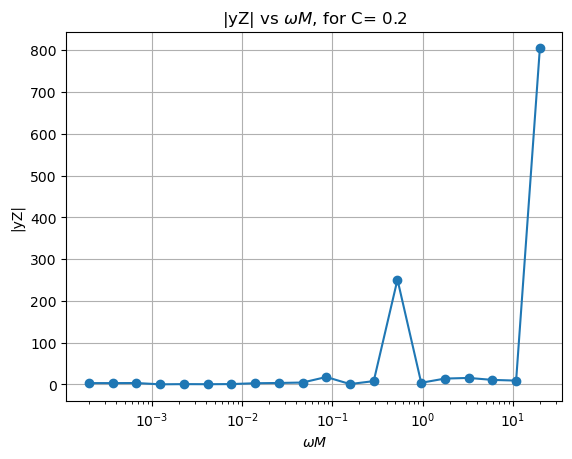

In [ ]:
plt.semilogx(np.logspace(-3, 2, 20)*M, yZ_vals, marker='o')
plt.xlabel(r"$\omega M$")
plt.ylabel("|yZ|")
plt.title(f"|yZ| vs $\omega M$, for C= 0.2")
plt.grid(True)
plt.show()

In [9]:
for omega in [1e-3, 0.1, 1.0]:
    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    print(omega, sol_surface)


0.001 [1.41089282e+24 0.00000000e+00 4.63843205e+29 0.00000000e+00
 4.18261174e+28 0.00000000e+00 9.44208392e+28 0.00000000e+00]
0.1 [1.16492694e-16 0.00000000e+00 6.38295195e-11 0.00000000e+00
 3.87327959e-14 0.00000000e+00 6.63994905e-14 0.00000000e+00]
1.0 [-4.75263256e-16  0.00000000e+00 -2.59487817e-10  0.00000000e+00
  5.97125112e-15  0.00000000e+00  1.55898386e-14  0.00000000e+00]
